# Explore Buildings Data

Do the inspection lat/lon coords line up with buildings?

In [ ]:
# Standard library imports
import os
import sys

# Third-party scientific libraries
import numpy as np
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import box

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

# Add project utilities to path
sys.path.append("../utils")

# Project imports
import config

### Import SB buildings data

In [2]:
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

buildings = gpd.read_file(sb_buildings_path)

### Check whether inspection points line up with buildings

#### Import inspections

In [3]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections



# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [4]:
# Unpack from dictionary
inspections_2019 = inspections_dict[2019]
inspections_2020 = inspections_dict[2020]
inspections_2021 = inspections_dict[2021]
inspections_2022 = inspections_dict[2022]
inspections_2023 = inspections_dict[2023]

In [5]:
inspections_2019.shape

(14675, 106)

#### Count number of inspections that fall outside of buildings

In [6]:
# Create a function that returns the number of inspections that fall outside building geometries for a given year
def inspections_within_buildings(year):
    """
    Function to return the number of inspections that fall within building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    # Use left join to keep all inspections
    joined = inspections.sjoin(buildings, predicate="intersects", how="left")

    # Inspections within buildings have a non-null index_right
    intersects = joined[~joined["index_right"].isna()]
    # Inspections outside buildings have a null index_right
    outside = joined[joined["index_right"].isna()]

    return intersects.drop(columns=["index_right"]), outside.drop(
        columns=["index_right"]
    )


# For loop to print number of inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    inspections_within, inspections_outside = inspections_within_buildings(year)
    print(
        f"{year} Inspections: \nWithin Buildings - {inspections_within.shape[0]} \nOutside of Buildings - {inspections_outside.shape[0]}\n"
    )

2019 Inspections: 
Within Buildings - 11011 
Outside of Buildings - 3664

2020 Inspections: 
Within Buildings - 9528 
Outside of Buildings - 2350

2021 Inspections: 
Within Buildings - 10491 
Outside of Buildings - 3521

2022 Inspections: 
Within Buildings - 10157 
Outside of Buildings - 3485

2023 Inspections: 
Within Buildings - 9919 
Outside of Buildings - 3454



#### Count number of non-compliant inspections that fall outside of buildings

In [7]:
# For loop to print number of non-compliant inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    non_comp_inspections_in, non_comp_inspections_out = inspections_within_buildings(
        year
    )
    non_comp_inspections_in = non_comp_inspections_in[
        non_comp_inspections_in["status"] == "Non-Compliant"
    ]
    non_comp_inspections_out = non_comp_inspections_out[
        non_comp_inspections_out["status"] == "Non-Compliant"
    ]
    print(
        f"{year} Non-Compliant Inspections: \nWithin Buildings - {non_comp_inspections_in.shape[0]} \nOutside of Buildings - {non_comp_inspections_out.shape[0]}\n"
    )

2019 Non-Compliant Inspections: 
Within Buildings - 72 
Outside of Buildings - 51

2020 Non-Compliant Inspections: 
Within Buildings - 74 
Outside of Buildings - 20

2021 Non-Compliant Inspections: 
Within Buildings - 63 
Outside of Buildings - 7

2022 Non-Compliant Inspections: 
Within Buildings - 47 
Outside of Buildings - 13

2023 Non-Compliant Inspections: 
Within Buildings - 54 
Outside of Buildings - 17



In [8]:
# Create a function that makes dataframes containing the number of non-compliant inspections that fall outside buildings for each year
def non_comp_inspections_outside(year):
    """
    Function to return the number of non-compliant inspections that fall outside building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    intersects = inspections.sjoin(buildings, predicate="intersects")

    non_comp_intersects = intersects[intersects["status"] == "Non-Compliant"]
    non_comp_outside = inspections.loc[
        ~inspections.index.isin(non_comp_intersects.index)
    ]
    non_comp_outside = non_comp_outside[non_comp_outside["status"] == "Non-Compliant"]

    return non_comp_intersects, non_comp_outside


# Get the number of non-compliant inspections that fall outside building geometries for each year
non_comp_2019, non_comp_2019_buildings_false = non_comp_inspections_outside(2019)
non_comp_2020, non_comp_2020_buildings_false = non_comp_inspections_outside(2020)
non_comp_2021, non_comp_2021_buildings_false = non_comp_inspections_outside(2021)
non_comp_2022, non_comp_2022_buildings_false = non_comp_inspections_outside(2022)
non_comp_2023, non_comp_2023_buildings_false = non_comp_inspections_outside(2023)


### Assign non-compliant inspections to nearby buildings

The minimum distance between buildings in CA is 10 feet (3.048 m). For this analysis, we will assign non-compliant inspections to the closest building within 3 meters. 

In [9]:
# Assign inspections to buildings if the distance between them is < 3 meters
def assign_inspections_to_buildings(inspections, buildings, distance_threshold=3):
    """
    Function to assign inspections to buildings if the distance between them is less than the distance threshold.
    """
    # Make a copy to avoid SettingWithCopyWarning
    inspections = inspections.copy()

    # Create a Spatial Index for faster search
    sindex = buildings.sindex

    # Find the nearest geometry in buildings for each geometry in inspections
    inspections["nearest_geometry"] = inspections.geometry.apply(
        lambda x: buildings.iloc[sindex.nearest(x)[1][0]].geometry
    )

    # Calculate the distance to the nearest geometry
    inspections["distance_to_nearest"] = inspections.apply(
        lambda row: row.geometry.distance(row.nearest_geometry), axis=1
    )

    # Assign inspections to buildings if the distance is less than the threshold
    assigned_inspections = inspections[
        inspections["distance_to_nearest"] < distance_threshold
    ].copy()

    return assigned_inspections


assigned_inspections_2019 = assign_inspections_to_buildings(inspections_2019, buildings)
assigned_inspections_2020 = assign_inspections_to_buildings(inspections_2020, buildings)
assigned_inspections_2021 = assign_inspections_to_buildings(inspections_2021, buildings)
assigned_inspections_2022 = assign_inspections_to_buildings(inspections_2022, buildings)
assigned_inspections_2023 = assign_inspections_to_buildings(inspections_2023, buildings)

### Workflow to process all inspections

In [10]:
# def process_inspections_by_year(year, buildings, distance_threshold=3):
#     """
#     Function to process inspections for a given year by:
#     1. Importing the inspections data
#     2. Performing spatial join with buildings
#     3. For ALL unmatched inspections (not just non-compliant ones),
#        assign them to the nearest building within the distance threshold
#     4. Combine all processed inspections into a single dataset
#     """
#     # Import the inspections data for the year
#     inspections = import_inspections_data(year)

#     # Create a copy of buildings with just geometry for the join
#     buildings_geom = buildings[["geometry"]].copy()

#     # Perform spatial join with buildings
#     inspections_with_buildings = inspections.sjoin(
#         buildings_geom, predicate="intersects", how="left"
#     )

#     # Split into matched and unmatched
#     matched_inspections = inspections_with_buildings[
#         ~inspections_with_buildings["index_right"].isna()
#     ].copy()
#     unmatched_inspections = inspections_with_buildings[
#         inspections_with_buildings["index_right"].isna()
#     ].copy()

#     # For matched inspections, replace point geometries with building polygons
#     if not matched_inspections.empty:
#         # Get indexes of matched buildings
#         building_indexes = matched_inspections["index_right"].astype(int).tolist()

#         # Get corresponding building geometries
#         building_geometries = buildings.iloc[building_indexes].geometry.tolist()

#         # Replace geometries
#         matched_inspections.geometry = building_geometries

#     # Create an empty list to store assigned inspections
#     assigned_inspections_list = []

#     # Process ALL unmatched inspections (not just non-compliant ones)
#     if not unmatched_inspections.empty:
#         # For each unmatched inspection
#         for idx, inspection in unmatched_inspections.iterrows():
#             # Use the spatial index to find the nearest building
#             nearest_idx = buildings.sindex.nearest(inspection.geometry)[1][0]
#             nearest_building = buildings.iloc[nearest_idx]

#             # Calculate the distance between the inspection and the nearest building
#             distance = inspection.geometry.distance(nearest_building.geometry)

#             # If within threshold, assign to this building
#             if distance < distance_threshold:
#                 # Create a new row with inspection data and building geometry
#                 assigned_inspection = inspection.copy()
#                 assigned_inspection.geometry = nearest_building.geometry

#                 # Add to assigned inspections list
#                 assigned_inspections_list.append(assigned_inspection)

#                 # Remove from unmatched inspections
#                 unmatched_inspections = unmatched_inspections.drop(idx)

#     # Convert list to GeoDataFrame if any inspections were assigned
#     if assigned_inspections_list:
#         assigned_inspections = gpd.GeoDataFrame(
#             assigned_inspections_list, crs=inspections.crs
#         )
#     else:
#         # Create an empty GeoDataFrame with the same structure as inspections
#         assigned_inspections = gpd.GeoDataFrame(
#             columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
#         )

#     # Clean up columns
#     matched_inspections = matched_inspections.drop(columns=["index_right"])
#     unmatched_inspections = unmatched_inspections.drop(columns=["index_right"])

#     # Combine all pieces - only add non-empty DataFrames
#     dfs_to_concat = [
#         df
#         for df in [matched_inspections, unmatched_inspections, assigned_inspections]
#         if not df.empty
#     ]
#     result = pd.concat(dfs_to_concat)

#     # Ensure it's a GeoDataFrame
#     result = gpd.GeoDataFrame(result, geometry="geometry", crs=inspections.crs)

#     # Print summary stats
#     print(f"Year {year} summary:")
#     print(f"  Original inspections: {len(inspections)}")
#     print(f"  Matched with buildings: {len(matched_inspections)}")
#     print(f"  Assigned to nearby buildings: {len(assigned_inspections)}")
#     print(f"  Remaining unmatched: {len(unmatched_inspections)}")
#     print(f"  Total processed: {len(result)}")
#     print()

#     return result


# # Process all years and store results in a dictionary
# processed_inspections = {}
# for year in range(2019, 2024):
#     processed_inspections[year] = process_inspections_by_year(year, buildings)
    
# # Save the processed datasets
# for year, data in processed_inspections.items():
#     output_path = os.path.join(
#         config.data_dir,
#         "joined_inspections_buildings",
#         f"inspections_with_buildings_{year}.geojson",
#     )
#     data.to_file(output_path, driver="GeoJSON")

Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Assigned to nearby buildings: 725
  Remaining unmatched: 2939
  Total processed: 14675



/tmp/ipykernel_3147144/4175155456.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(dfs_to_concat)


Year 2020 summary:
  Original inspections: 11878
  Matched with buildings: 9528
  Assigned to nearby buildings: 586
  Remaining unmatched: 1764
  Total processed: 11878

Year 2021 summary:
  Original inspections: 14012
  Matched with buildings: 10491
  Assigned to nearby buildings: 668
  Remaining unmatched: 2853
  Total processed: 14012



/tmp/ipykernel_3147144/4175155456.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(dfs_to_concat)


Year 2022 summary:
  Original inspections: 13642
  Matched with buildings: 10157
  Assigned to nearby buildings: 652
  Remaining unmatched: 2833
  Total processed: 13642



/tmp/ipykernel_3147144/4175155456.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(dfs_to_concat)


Year 2023 summary:
  Original inspections: 13373
  Matched with buildings: 9919
  Assigned to nearby buildings: 625
  Remaining unmatched: 2829
  Total processed: 13373



## Plot processed data (2019)

In [ ]:
# processed_2019 = processed_inspections[2019]

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 10))

# # First plot the points
# processed_2019[processed_2019.geometry.geom_type == "Point"].plot(
#     ax=ax, color="red", markersize=5, label="Points"
# )

# # Then plot the building polygons
# processed_2019[processed_2019.geometry.geom_type == "Polygon"].plot(
#     ax=ax, color="blue", alpha=0.7, label="Polygons", edgecolor="black", linewidth=0.5
# )

# # Add a legend and title
# ax.legend(loc="upper right")
# ax.set_title("Inspections 2019: Points and Polygons", fontsize=14)
# plt.tight_layout()
# plt.show()

# # Create two separate plots for both points and polygons
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# # Plot only points on the first subplot
# processed_2019[processed_2019.geometry.geom_type == "Point"].plot(
#     ax=ax1, color="red", markersize=5
# )
# ax1.set_title("Points Only")

# # Plot only polygons on the second subplot
# processed_2019[processed_2019.geometry.geom_type == "Polygon"].plot(
#     ax=ax2, color="blue", alpha=0.5, edgecolor="black", linewidth=0.5
# )
# ax2.set_title("Polygons Only")

# plt.tight_layout()
# plt.show()

## Revised workflow: create polygon geometries for all inspections with missing polygon geometries using the average building area

In [13]:
def process_inspections_by_year(year, buildings, distance_threshold=3):
    """
    Function to process inspections for a given year by:
    1. Importing the inspections data
    2. Performing spatial join with buildings
    3. For ALL unmatched inspections, assign them to the nearest building within the distance threshold
       or create a square geometry with the average building area
    4. Combine all processed inspections into a single dataset
    """
    # Import the inspections data for the year
    inspections = import_inspections_data(year)
    
    # Calculate the average building area
    avg_building_area = buildings.geometry.area.mean()
    side_length = np.sqrt(avg_building_area)  # Square root to get side length
    
    print(f"Average building area: {avg_building_area:.2f} square units")
    print(f"Square side length: {side_length:.2f} units")
    
    # Create a copy of buildings with just geometry for the join
    buildings_geom = buildings[["geometry"]].copy()

    # Perform spatial join with buildings
    inspections_with_buildings = inspections.sjoin(
        buildings_geom, predicate="intersects", how="left"
    )

    # Split into matched and unmatched
    matched_inspections = inspections_with_buildings[
        ~inspections_with_buildings["index_right"].isna()
    ].copy()
    unmatched_inspections = inspections_with_buildings[
        inspections_with_buildings["index_right"].isna()
    ].copy()

    # For matched inspections, replace point geometries with building polygons
    if not matched_inspections.empty:
        # Get indexes of matched buildings
        building_indexes = matched_inspections["index_right"].astype(int).tolist()

        # Get corresponding building geometries
        building_geometries = buildings.iloc[building_indexes].geometry.tolist()

        # Replace geometries
        matched_inspections.geometry = building_geometries

    # Create an empty list to store assigned inspections
    assigned_inspections_list = []
    # Create an empty list for inspections with new square geometries
    square_inspections_list = []

    # Process ALL unmatched inspections
    if not unmatched_inspections.empty:
        # For each unmatched inspection
        for idx, inspection in unmatched_inspections.iterrows():
            # Use the spatial index to find the nearest building
            nearest_idx = buildings.sindex.nearest(inspection.geometry)[1][0]
            nearest_building = buildings.iloc[nearest_idx]

            # Calculate the distance between the inspection and the nearest building
            distance = inspection.geometry.distance(nearest_building.geometry)

            # If within threshold, assign to this building
            if distance < distance_threshold:
                # Create a new row with inspection data and building geometry
                assigned_inspection = inspection.copy()
                assigned_inspection.geometry = nearest_building.geometry

                # Add to assigned inspections list
                assigned_inspections_list.append(assigned_inspection)
            else:
                # Create a square with area equal to the average building area
                # centered on the inspection point
                point = inspection.geometry
                x, y = point.x, point.y
                
                # Create a square centered on the point
                half_side = side_length / 2
                square = box(x - half_side, y - half_side, x + half_side, y + half_side)
                
                # Create a new row with inspection data and square geometry
                square_inspection = inspection.copy()
                square_inspection.geometry = square
                
                # Add to square inspections list
                square_inspections_list.append(square_inspection)

    # Convert lists to GeoDataFrames if any inspections were processed
    if assigned_inspections_list:
        assigned_inspections = gpd.GeoDataFrame(
            assigned_inspections_list, crs=inspections.crs
        )
    else:
        assigned_inspections = gpd.GeoDataFrame(
            columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
        )
        
    if square_inspections_list:
        square_inspections = gpd.GeoDataFrame(
            square_inspections_list, crs=inspections.crs
        )
    else:
        square_inspections = gpd.GeoDataFrame(
            columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
        )

    # Clean up columns
    matched_inspections = matched_inspections.drop(columns=["index_right"])
    
    # Combine all pieces - only add non-empty DataFrames
    dfs_to_concat = [
        df
        for df in [matched_inspections, assigned_inspections, square_inspections]
        if not df.empty
    ]
    result = pd.concat(dfs_to_concat)

    # Ensure it's a GeoDataFrame
    result = gpd.GeoDataFrame(result, geometry="geometry", crs=inspections.crs)

    # Print summary stats
    print(f"Year {year} summary:")
    print(f"  Original inspections: {len(inspections)}")
    print(f"  Matched with buildings: {len(matched_inspections)}")
    print(f"  Assigned to nearby buildings: {len(assigned_inspections)}")
    print(f"  Created square geometries: {len(square_inspections)}")
    print(f"  Total processed: {len(result)}")
    print()

    return result


# Process all years and store results in a dictionary
processed_inspections = {}
for year in range(2019, 2024):
    processed_inspections[year] = process_inspections_by_year(year, buildings)
    
# Save the processed datasets
for year, data in processed_inspections.items():
    output_path = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Assigned to nearby buildings: 725
  Created square geometries: 2939
  Total processed: 14675

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2020 summary:
  Original inspections: 11878
  Matched with buildings: 9528
  Assigned to nearby buildings: 586
  Created square geometries: 1764
  Total processed: 11878

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2021 summary:
  Original inspections: 14012
  Matched with buildings: 10491
  Assigned to nearby buildings: 668
  Created square geometries: 2853
  Total processed: 14012

Average building area: 284.05 square units
Square side length: 16.85 units


/tmp/ipykernel_3147144/2041526630.py:116: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(dfs_to_concat)


Year 2022 summary:
  Original inspections: 13642
  Matched with buildings: 10157
  Assigned to nearby buildings: 652
  Created square geometries: 2833
  Total processed: 13642

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2023 summary:
  Original inspections: 13373
  Matched with buildings: 9919
  Assigned to nearby buildings: 625
  Created square geometries: 2829
  Total processed: 13373



### Plot the processed geometries (2019)

/tmp/ipykernel_3147144/2092179107.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")
/tmp/ipykernel_3147144/2092179107.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


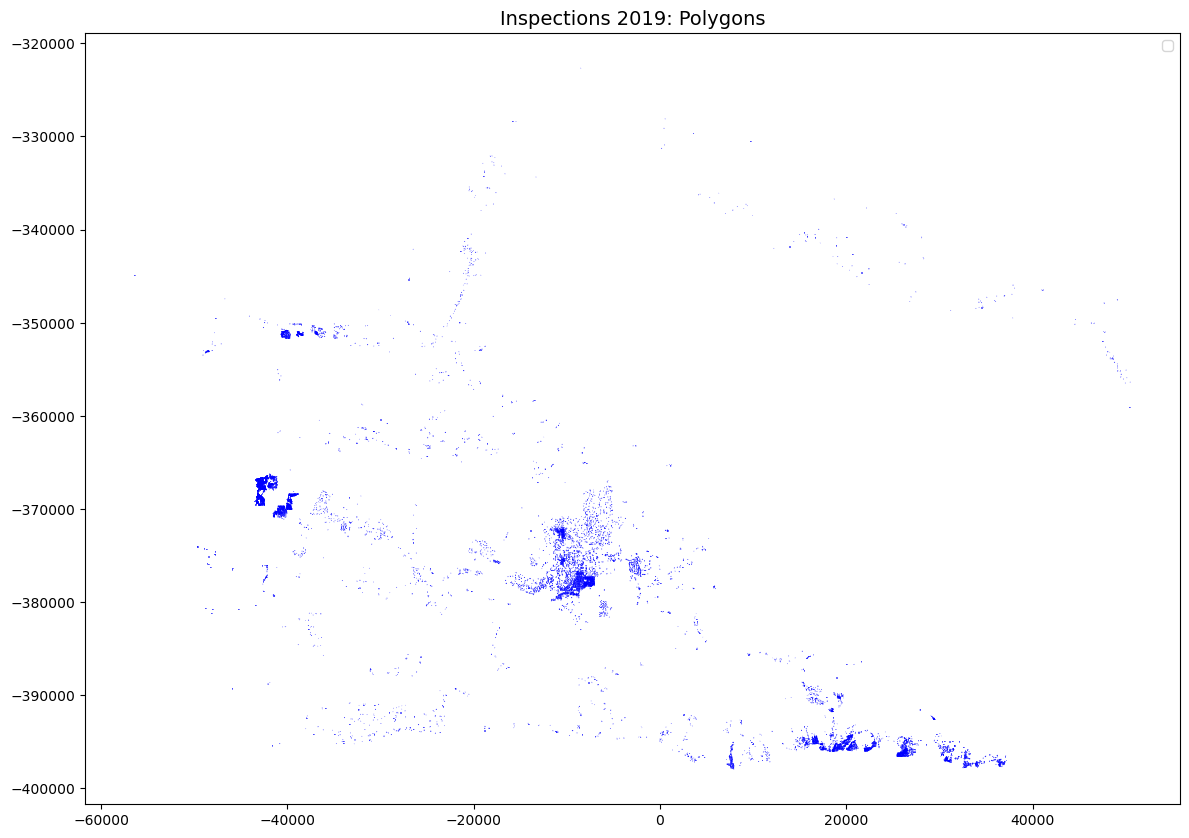

In [14]:
processed_2019 = processed_inspections[2019]

fig, ax = plt.subplots(figsize=(12, 10))

# Then plot the building polygons
processed_2019.plot(
    ax=ax, color="blue", alpha=0.7, label="Polygons", edgecolor="blue", linewidth=0.5
)

# Add a legend and title
ax.legend(loc="upper right")
ax.set_title("Inspections 2019: Polygons", fontsize=14)
plt.tight_layout()
plt.show()